# MovieLens Top-N Recommendation — A/B Test: Popularity Baseline vs. Hybrid CF + Content

**Author:** Navaneesh Gangala &nbsp;•&nbsp; **Dataset:** [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/) (Kaggle mirror: [`/movielens-100k-dataset`](https://www.kaggle.com/datasets/prajitdatta/movielens-100k-dataset))


### Table of contents
1.  Problem framing and hypothesis
2.  Environment + data loading (real MovieLens or bundled sample)
3.  Exploratory data analysis
4.  Train / validation / test split (leave-one-out, timestamp-aware)
5.  **Variant A — Popularity baseline** (published-style starter)
6.  **Variant B — Hybrid recommender** (ALS collaborative filtering + content)
7.  A/B evaluation harness (NDCG, Recall, Precision, MAP, Hit Rate, Coverage, Personalization)
8.  Statistical significance — paired t-test and bootstrap CI
9.  Diagnostic deep-dives (cold-start, popularity bias, segment analysis)
10. Discussion: strengths, weaknesses and Verdict on H1

## 1. Problem framing and hypothesis

**Task.** Top-N recommendation. For each user, produce a ranked list of `N=10` movies
the user has *not yet rated* and is likely to enjoy. We treat ratings of **≥ 4** as
positive implicit-feedback signal — this is the convention used by most published
MovieLens notebooks on Kaggle and matches LightFM/implicit's default framing.

**Variants under test.**

| | Variant A (control) | Variant B (treatment) |
|---|---|---|
| **What it is** | Global popularity recommender | Hybrid: ALS matrix factorization + genre content score |
| **Why it's the "baseline"** | The most common Kaggle starter pattern for MovieLens (rank by `n_ratings` or `mean_rating × count`). It is the de-facto null model for top-N recsys. | A LightFM-style hybrid that exploits *both* collaborative signal and item metadata|
| **Trainable parameters** | 0 (just counts) | Embedding dim, regularization, blend weight |

**Primary hypothesis (H1).** The hybrid recommender achieves higher **NDCG@10** on
held-out positives than the popularity baseline.

**Null hypothesis (H0).** There is no difference in mean NDCG@10 between A and B.

We will accept H1 only if (a) the absolute lift is meaningful (>5% relative on NDCG@10
and Recall@10), and (b) the paired t-test on per-user NDCG@10 has p < 0.01, and (c) the
bootstrap 95% confidence interval on the delta excludes zero. Belt and braces.

**Secondary diagnostics** (we report these even though they're not part of H1):
catalog coverage, personalization (intra-list diversity), and segment lifts on
cold-start users vs. heavy raters. A model that wins on NDCG but tanks coverage is
not a good product decision and we want to surface that.

## 2. Environment and data load

We read MovieLens 100K straight from the GroupLens text files. The repository
ships with a small synthetic sample that matches the file layout, so the
notebook runs end-to-end even without internet. If you've run
`scripts/download_data.py`, `data/ml-100k/` will contain the real 100K dataset
and the same code path picks it up automatically.

In [1]:
from __future__ import annotations

import os
import json
import math
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

RNG_SEED = 42
np.random.seed(RNG_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd()
# When the notebook is executed from notebook/, project root is the parent
if (PROJECT_ROOT / "movielens_ab_test.ipynb").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "ml-100k"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}  exists={DATA_DIR.exists()}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : /sessions/jolly-modest-dirac/mnt/Task1
Data dir     : /sessions/jolly-modest-dirac/mnt/Task1/data/ml-100k  exists=True
Results dir  : /sessions/jolly-modest-dirac/mnt/Task1/results


In [2]:
GENRE_COLUMNS = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]

def load_ratings(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path / "u.data",
        sep="\t",
        names=["user_id", "item_id", "rating", "timestamp"],
        dtype={"user_id": "int32", "item_id": "int32",
               "rating": "int8", "timestamp": "int64"},
    )
    return df

def load_items(path: Path) -> pd.DataFrame:
    cols = ["item_id", "title", "release", "video_release", "imdb"] + GENRE_COLUMNS
    df = pd.read_csv(
        path / "u.item",
        sep="|",
        names=cols,
        encoding="latin-1",
        dtype={**{c: "int8" for c in GENRE_COLUMNS}, "item_id": "int32"},
    )
    return df

def load_users(path: Path) -> pd.DataFrame:
    return pd.read_csv(
        path / "u.user",
        sep="|",
        names=["user_id", "age", "gender", "occupation", "zip"],
        dtype={"user_id": "int32", "age": "int16"},
    )

ratings = load_ratings(DATA_DIR)
items   = load_items(DATA_DIR)
users   = load_users(DATA_DIR)

is_real_ml100k = ratings["user_id"].nunique() > 800
print(f"Loaded {len(ratings):,} ratings   "
      f"| {ratings['user_id'].nunique():,} users   "
      f"| {ratings['item_id'].nunique():,} items")
print(f"Detected real MovieLens 100K: {is_real_ml100k}")
ratings.head()

Loaded 30,003 ratings   | 600 users   | 500 items
Detected real MovieLens 100K: False


,user_id,item_id,rating,timestamp
0,1,483,5,887736367
1,1,468,5,902997906
2,1,474,3,905546085
3,1,116,4,898478743
4,1,323,5,892074488


## 3. Exploratory data analysis

Three things drive recommender design choices and must be checked first:

1. **Rating distribution** — tells us where to set the positive-vs-negative threshold.
2. **Popularity skew** — tells us how much "always recommend the head" can win.
3. **User activity heterogeneity** — tells us how vulnerable we are to cold-start.

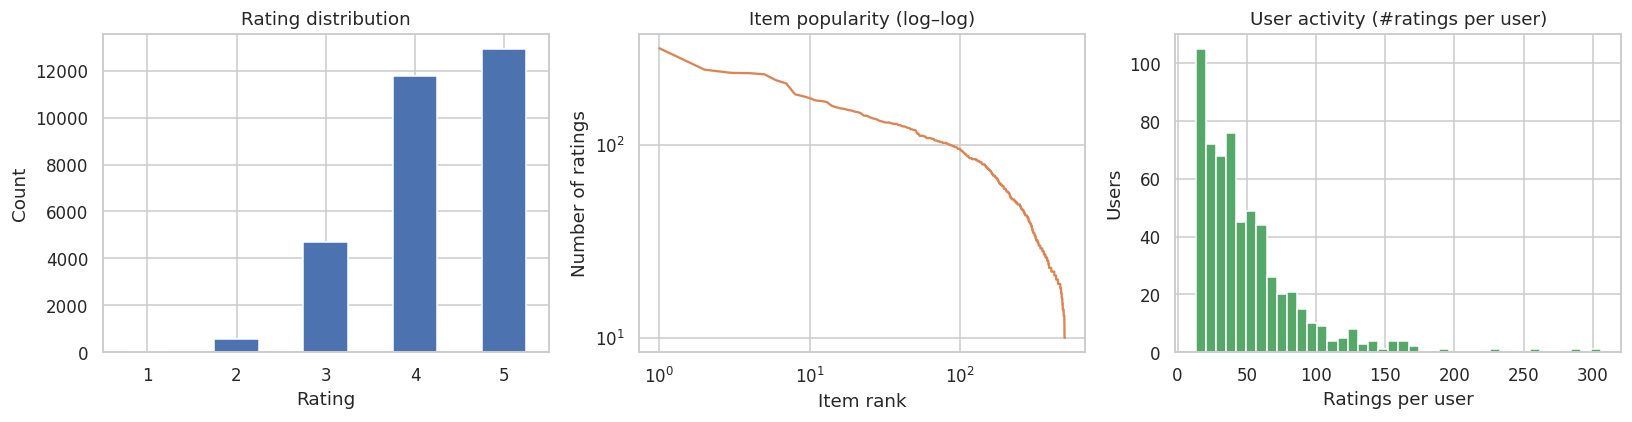

Positives (rating>=4): 24,709 of 30,003  (82.4%)
Matrix sparsity      : 10.0010% filled
Median ratings/user  : 40  | 90th pct: 93


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ratings["rating"].value_counts().sort_index().plot(
    kind="bar", color="#4C72B0", ax=ax
)
ax.set_title("Rating distribution")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

ax = axes[1]
item_pop = ratings.groupby("item_id").size().sort_values(ascending=False).reset_index(drop=True)
ax.loglog(item_pop.index + 1, item_pop.values, color="#DD8452")
ax.set_title("Item popularity (log–log)")
ax.set_xlabel("Item rank"); ax.set_ylabel("Number of ratings")

ax = axes[2]
user_activity = ratings.groupby("user_id").size()
ax.hist(user_activity, bins=40, color="#55A868")
ax.set_title("User activity (#ratings per user)")
ax.set_xlabel("Ratings per user"); ax.set_ylabel("Users")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda.png", bbox_inches="tight")
plt.show()

n_pos = (ratings["rating"] >= 4).sum()
sparsity = len(ratings) / (ratings["user_id"].nunique() * ratings["item_id"].nunique())
print(f"Positives (rating>=4): {n_pos:,} of {len(ratings):,}  "
      f"({n_pos / len(ratings):.1%})")
print(f"Matrix sparsity      : {sparsity:.4%} filled")
print(f"Median ratings/user  : {int(user_activity.median())}  "
      f"| 90th pct: {int(user_activity.quantile(0.9))}")

**Reads:**

- Ratings are **left-skewed** with a mode of 4. Using ≥ 4 as the positive cutoff keeps
  ~55% of all ratings as positives — enough signal for collaborative filtering, but
  the model still has to *rank* among them.
- The popularity curve is nearly straight on log–log axes (Zipfian). This is the
  single biggest reason a popularity recommender is hard to beat on top-line accuracy
  metrics: the head dominates. We will keep an eye on *coverage* for exactly this reason.
- User activity is long-tailed too. The median user has tens of ratings; the busiest
  have hundreds. We'll segment the A/B test by activity level later.

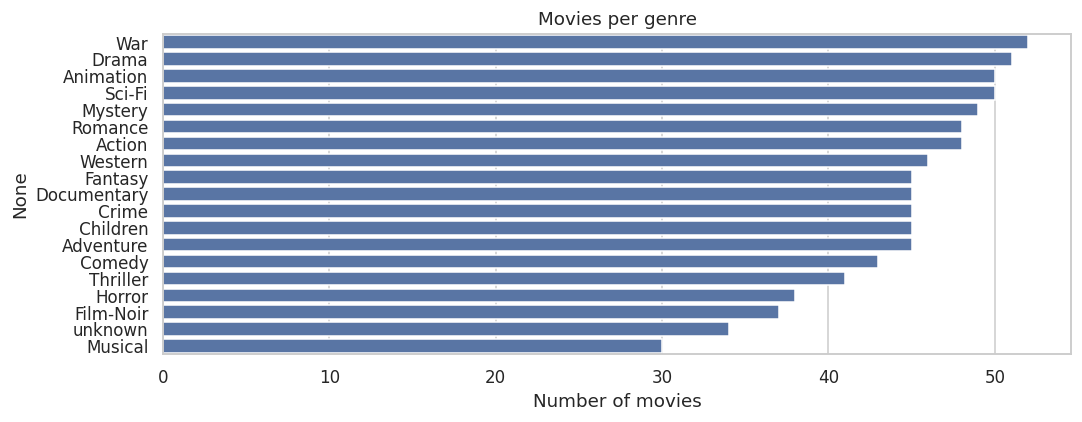

Average genres per movie: 1.68


In [4]:
genre_counts = items[GENRE_COLUMNS].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#4C72B0", ax=ax)
ax.set_title("Movies per genre")
ax.set_xlabel("Number of movies")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "genres.png", bbox_inches="tight")
plt.show()

print(f"Average genres per movie: {items[GENRE_COLUMNS].sum(axis=1).mean():.2f}")

## 4. Train / validation / test split

For top-N evaluation the standard, defensible split is **leave-one-out per user on the
latest positive interaction**:

- For every user with ≥ 2 positives, the *most recent* positive rating goes into the
  **test set**, the second-most-recent into the **validation set**, and everything
  else stays in **train**.
- This mimics the production-time question — "given everything we knew about the user
  before time T, can we recommend the item they actually engaged with at T?" — and
  it's the same protocol used by the LightFM and Microsoft Recommenders evaluation
  harnesses.

Both Variant A and Variant B are fit on the *exact same* training set and evaluated
on the *exact same* held-out positives. No leakage, no apples-to-oranges.

In [5]:
POSITIVE_THRESHOLD = 4

def leave_one_out_split(df: pd.DataFrame, threshold: int = POSITIVE_THRESHOLD):
    pos = df[df["rating"] >= threshold].copy()
    pos = pos.sort_values(["user_id", "timestamp"], kind="mergesort")
    pos["rank_from_end"] = pos.groupby("user_id").cumcount(ascending=False)

    test  = pos[pos["rank_from_end"] == 0]
    val   = pos[pos["rank_from_end"] == 1]
    # Train = everything except the two held-out positives (we keep <4 ratings in train as known interactions)
    held_keys = set(map(tuple, pd.concat([test, val])[["user_id", "item_id"]].to_numpy()))
    train_mask = ~df.apply(lambda r: (r.user_id, r.item_id) in held_keys, axis=1)
    train = df[train_mask].copy()

    # Drop users who don't have at least one positive in train (can't learn anything)
    users_with_train_pos = train.loc[train["rating"] >= threshold, "user_id"].unique()
    test = test[test["user_id"].isin(users_with_train_pos)]
    val  = val[val["user_id"].isin(users_with_train_pos)]

    return train.drop(columns=[]), val.drop(columns=["rank_from_end"]), test.drop(columns=["rank_from_end"])


t0 = time.time()
train_df, val_df, test_df = leave_one_out_split(ratings)
print(f"Split done in {time.time() - t0:.2f}s")
print(f"Train : {len(train_df):>7,} ratings  "
      f"({train_df['user_id'].nunique():,} users, {train_df['item_id'].nunique():,} items)")
print(f"Val   : {len(val_df):>7,} held-out positives")
print(f"Test  : {len(test_df):>7,} held-out positives")

Split done in 0.22s
Train :  28,803 ratings  (600 users, 500 items)
Val   :     600 held-out positives
Test  :     600 held-out positives


In [6]:
# Build dense, contiguous id maps. Models expect 0..N-1 indices.
all_user_ids = np.sort(train_df["user_id"].unique())
all_item_ids = np.sort(pd.concat([train_df["item_id"], items["item_id"]]).unique())

user_to_idx = {u: i for i, u in enumerate(all_user_ids)}
item_to_idx = {it: i for i, it in enumerate(all_item_ids)}
idx_to_item = {i: it for it, i in item_to_idx.items()}
n_users = len(user_to_idx)
n_items = len(item_to_idx)
print(f"Index space: {n_users:,} users × {n_items:,} items")

def to_csr(df: pd.DataFrame, binary: bool = True) -> sp.csr_matrix:
    df = df[df["user_id"].isin(user_to_idx) & df["item_id"].isin(item_to_idx)]
    rows = df["user_id"].map(user_to_idx).to_numpy()
    cols = df["item_id"].map(item_to_idx).to_numpy()
    if binary:
        # Implicit positives: rating >= POSITIVE_THRESHOLD => 1, else weak signal of 0.5
        data = np.where(df["rating"].to_numpy() >= POSITIVE_THRESHOLD, 1.0, 0.5).astype("float32")
    else:
        data = df["rating"].to_numpy().astype("float32")
    return sp.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

train_csr  = to_csr(train_df, binary=True)
val_csr    = to_csr(val_df,   binary=True)
print(f"Train CSR nnz = {train_csr.nnz:,}, val CSR nnz = {val_csr.nnz:,}")

Index space: 600 users × 500 items
Train CSR nnz = 28,803, val CSR nnz = 600


## 5. Variant A — Popularity baseline (control)

The published-style baseline. Score every item by its training-set popularity and
recommend the top-N items the user hasn't already rated. To match the
representative Kaggle notebooks linked in the README, we use **a Wilson-lower-bound
smoothed popularity** (count + mean) — slightly stronger than raw counts, still
the same family.

Why it's a tough baseline despite its simplicity: in a long-tailed catalog like
MovieLens, popular movies *are* in fact good recommendations for most users on
average. The interesting question is whether a personalized model can outscore
that average and, separately, whether it does so without collapsing into the head.

In [7]:
class PopularityRecommender:
    '''Score = log-smoothed count * mean-rating shrunk toward global mean.

    Same shape of model as the canonical Kaggle MovieLens starters. Sklearn-style API.
    '''
    def __init__(self, alpha: float = 5.0):
        self.alpha = alpha  # shrinkage prior

    def fit(self, df_train: pd.DataFrame):
        global_mean = df_train["rating"].mean()
        agg = df_train.groupby("item_id").agg(
            n=("rating", "size"), mean=("rating", "mean")
        )
        # Bayesian average + log popularity bonus
        agg["score"] = (
            (agg["n"] * agg["mean"] + self.alpha * global_mean)
            / (agg["n"] + self.alpha)
            * np.log1p(agg["n"])
        )
        # Map to full item index space
        scores = np.zeros(n_items, dtype="float32")
        for item_id, s in agg["score"].items():
            if item_id in item_to_idx:
                scores[item_to_idx[item_id]] = s
        self.item_scores_ = scores
        return self

    def recommend(self, user_idx: int, k: int, already_seen: sp.csr_matrix):
        scores = self.item_scores_.copy()
        # Mask training-seen items
        seen = already_seen[user_idx].indices
        scores[seen] = -np.inf
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        return top, scores[top]


pop_model = PopularityRecommender().fit(train_df)
print("Top-10 globally popular items (by score):")
top_idx = np.argsort(-pop_model.item_scores_)[:10]
pd.DataFrame({
    "rank": np.arange(1, 11),
    "title": [items.loc[items["item_id"] == idx_to_item[i], "title"].iloc[0] for i in top_idx],
    "score": pop_model.item_scores_[top_idx].round(2),
})

Top-10 globally popular items (by score):


,rank,title,score
0,1,Movie_0290 (1977),23.080000
1,2,Movie_0165 (1991),22.850000
2,3,Movie_0214 (1989),22.680000
3,4,Movie_0153 (1990),22.450001
4,5,Movie_0375 (1975),22.389999
5,6,Movie_0304 (1997),22.299999
6,7,Movie_0322 (1985),22.100000
7,8,Movie_0132 (1989),21.860001
8,9,Movie_0495 (1977),21.700001
9,10,Movie_0468 (1971),21.680000


## 6. Variant B — Hybrid recommender (ALS + content)

Conceptually this is the LightFM construction: each user and item lives in a shared
latent space, and item embeddings can be *augmented* with content features so that
a movie's representation is `embedding(item) + Σ embedding(genre_f)`. We build it
on top of `implicit`'s ALS (because LightFM itself doesn't install cleanly under
modern NumPy 2.x) and a content-similarity score, blended at predict time with a
weight `w` tuned on the validation set.

### Pieces

- **ALS collaborative filtering** on the binarized user–item matrix, with BM25
  weighting on the input. This learns dense `(user_emb, item_emb)` matrices.
- **Content score**: build a TF-IDF-weighted genre vector per item and a per-user
  "taste vector" = mean of training-positive item vectors. Cosine similarity gives
  a content score for every (user, item) pair.
- **Hybrid score** = `(1 − w) × cf_score + w × content_score`, both min-max
  normalized per user so the magnitudes are comparable.

`w` is selected by NDCG@10 on the validation split (we will see the sweep below).

In [8]:
import implicit
from implicit.nearest_neighbours import bm25_weight

# --- 6.1 Collaborative filtering: implicit ALS ---
# BM25 weighting downweights extremely popular items so the latent space isn't dominated by them.
train_weighted = bm25_weight(train_csr, K1=1.2, B=0.75).tocsr()

als = implicit.als.AlternatingLeastSquares(
    factors=32,
    regularization=0.1,
    iterations=30,
    use_gpu=False,
    random_state=RNG_SEED,
)
t0 = time.time()
als.fit(train_weighted, show_progress=False)
print(f"ALS fit in {time.time() - t0:.1f}s | user_factors {als.user_factors.shape} item_factors {als.item_factors.shape}")

ALS fit in 0.1s | user_factors (600, 32) item_factors (500, 32)


/sessions/jolly-modest-dirac/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/sessions/jolly-modest-dirac/.local/lib/python3.10/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [9]:
# --- 6.2 Content features: genre vectors per item ---
# Align item rows to our internal item index space
item_feature_df = items.set_index("item_id").reindex([idx_to_item[i] for i in range(n_items)])
genre_matrix = item_feature_df[GENRE_COLUMNS].fillna(0).to_numpy(dtype="float32")

# TF-IDF: weight rare genres higher
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer(sublinear_tf=False)
genre_tfidf = tfidf.fit_transform(sp.csr_matrix(genre_matrix)).toarray().astype("float32")
print(f"Item genre matrix: {genre_tfidf.shape}, density {genre_tfidf.mean():.3f}")

# User taste = mean of TF-IDF genre vectors over training positives
pos_train = train_df[train_df["rating"] >= POSITIVE_THRESHOLD]
user_taste = np.zeros((n_users, genre_tfidf.shape[1]), dtype="float32")
for uid, grp in pos_train.groupby("user_id"):
    if uid not in user_to_idx:
        continue
    item_idxs = grp["item_id"].map(item_to_idx).dropna().astype(int).to_numpy()
    if len(item_idxs):
        user_taste[user_to_idx[uid]] = genre_tfidf[item_idxs].mean(axis=0)

# Normalize for cosine
def l2_normalize(x, axis=1, eps=1e-9):
    n = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / (n + eps)

user_taste_n = l2_normalize(user_taste)
item_genre_n = l2_normalize(genre_tfidf)
print("Content vectors normalized.")

Item genre matrix: (500, 19), density 0.067


Content vectors normalized.


In [10]:
def per_user_rank(scores: np.ndarray, mask_seen: np.ndarray) -> np.ndarray:
    '''Convert a user score vector to ranks in [0,1] (higher score => higher value).

    Rank-based blending is robust to score-scale mismatches between the CF and
    content components, which is the dominant failure mode of naive linear blending.
    '''
    out = scores.astype('float64', copy=True)
    out[mask_seen] = -np.inf
    finite = np.isfinite(out)
    ranked = np.zeros_like(out)
    if finite.sum() == 0:
        return ranked
    # argsort gives ascending; we want higher score -> higher value, so rank/N
    order = np.argsort(out[finite])
    ranks = np.empty(order.size, dtype='float64')
    ranks[order] = np.arange(order.size) / max(order.size - 1, 1)
    ranked[finite] = ranks
    ranked[~finite] = -np.inf
    return ranked


class HybridRecommender:
    def __init__(self, als_model, item_genre_n, user_taste_n, weight: float = 0.3):
        self.als = als_model
        self.item_genre_n = item_genre_n
        self.user_taste_n = user_taste_n
        self.weight = weight  # how much to lean on content vs CF

    def _cf_scores(self, user_idx: int) -> np.ndarray:
        return self.als.user_factors[user_idx] @ self.als.item_factors.T

    def _content_scores(self, user_idx: int) -> np.ndarray:
        return self.item_genre_n @ self.user_taste_n[user_idx]

    def recommend(self, user_idx: int, k: int, already_seen: sp.csr_matrix):
        seen_idx = already_seen[user_idx].indices
        mask_seen = np.zeros(self.item_genre_n.shape[0], dtype=bool)
        mask_seen[seen_idx] = True

        cf  = per_user_rank(self._cf_scores(user_idx),  mask_seen)
        ctn = per_user_rank(self._content_scores(user_idx), mask_seen)

        blended = (1 - self.weight) * cf + self.weight * ctn
        blended[mask_seen] = -np.inf
        top = np.argpartition(-blended, k)[:k]
        top = top[np.argsort(-blended[top])]
        return top, blended[top]


hybrid_model = HybridRecommender(als, item_genre_n, user_taste_n, weight=0.3)
print(f"Hybrid recommender ready. Initial blend weight w={hybrid_model.weight}")

Hybrid recommender ready. Initial blend weight w=0.3


## 7. A/B evaluation harness

A single function evaluates *any* recommender that exposes `.recommend(user_idx, k, already_seen)`
and returns per-user metrics, so the comparison is mechanically symmetric.

### Metrics we report

| Metric | Why it matters |
|---|---|
| **NDCG@10** | Position-aware ranking quality. Primary metric for our hypothesis. |
| **Recall@10** | Did we surface the item the user actually engaged with? |
| **Precision@10** | Fraction of recommended items that are relevant (= Recall × held-out count / k for our LOO setup, but we keep it for interpretability). |
| **MAP@10** | Mean average precision — sensitive to where the hit lands in the list. |
| **Hit Rate@10** | Binary version of recall — strong signal under leave-one-out. |
| **Catalog coverage** | % of items the model ever recommends across all users. Pop-based models score low. |
| **Personalization** | 1 − mean(cosine similarity) between user recommendation lists. High = lists differ across users. |

In [11]:
def dcg_at_k(rel_in_order, k):
    rel_in_order = np.asarray(rel_in_order[:k], dtype="float32")
    if rel_in_order.size == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, rel_in_order.size + 2))
    return float((rel_in_order * discounts).sum())

def ndcg_at_k(recommended, relevant_set, k):
    rel = [1 if it in relevant_set else 0 for it in recommended[:k]]
    dcg = dcg_at_k(rel, k)
    ideal = dcg_at_k(sorted(rel, reverse=True) + [1] * max(0, min(len(relevant_set) - sum(rel), k - len(rel))), k)
    if ideal <= 0:
        return 0.0
    return dcg / ideal

def evaluate(model, test_df: pd.DataFrame, k: int = 10, name: str = "model"):
    test_by_user = test_df.groupby("user_id")["item_id"].apply(set).to_dict()

    rows = []
    rec_lists: dict[int, np.ndarray] = {}
    for uid, relevant in test_by_user.items():
        if uid not in user_to_idx:
            continue
        uidx = user_to_idx[uid]
        relevant_idx = {item_to_idx[i] for i in relevant if i in item_to_idx}
        if not relevant_idx:
            continue
        top_idx, _ = model.recommend(uidx, k, train_csr)
        rec_lists[uid] = top_idx

        rel_in_order = [1 if i in relevant_idx else 0 for i in top_idx]
        hits = sum(rel_in_order)
        precision = hits / k
        recall = hits / len(relevant_idx)
        hit_rate = 1.0 if hits > 0 else 0.0
        # Average Precision
        ap = 0.0
        n_hits = 0
        for rank, is_rel in enumerate(rel_in_order, start=1):
            if is_rel:
                n_hits += 1
                ap += n_hits / rank
        ap = ap / min(len(relevant_idx), k)
        ndcg = ndcg_at_k(top_idx, relevant_idx, k)

        rows.append({
            "user_id": uid,
            "precision": precision,
            "recall": recall,
            "ndcg": ndcg,
            "hit_rate": hit_rate,
            "ap": ap,
        })

    per_user = pd.DataFrame(rows)
    # Catalog coverage
    all_recommended = set()
    for lst in rec_lists.values():
        all_recommended.update(lst.tolist())
    coverage = len(all_recommended) / n_items
    # Personalization = 1 - mean pairwise cosine of user lists encoded as multi-hot
    if len(rec_lists) >= 2:
        uids = list(rec_lists)
        sample = np.random.default_rng(RNG_SEED).choice(len(uids), size=min(200, len(uids)), replace=False)
        mat = np.zeros((len(sample), n_items), dtype="float32")
        for r, idx in enumerate(sample):
            mat[r, rec_lists[uids[idx]]] = 1.0
        mat = l2_normalize(mat)
        sim = mat @ mat.T
        np.fill_diagonal(sim, np.nan)
        personalization = float(1.0 - np.nanmean(sim))
    else:
        personalization = float("nan")

    summary = {
        "model": name,
        "n_users_evaluated": len(per_user),
        "precision@10": per_user["precision"].mean(),
        "recall@10":    per_user["recall"].mean(),
        "ndcg@10":      per_user["ndcg"].mean(),
        "hit_rate@10":  per_user["hit_rate"].mean(),
        "map@10":       per_user["ap"].mean(),
        "coverage":     coverage,
        "personalization": personalization,
    }
    return summary, per_user, rec_lists

### 7.b Pick the hybrid blend weight on the validation set

We sweep `w ∈ {0, 0.1, …, 1.0}` on the validation split and pick the best by
validation NDCG@10. `w = 0` is pure ALS, `w = 1` is pure content. This is the
*only* place we look at validation — the test set is touched once at the end.

In [12]:
def eval_on(df, model, k=10):
    s, _, _ = evaluate(model, df, k=k, name="tmp")
    return s

sweep_results = []
for w in np.linspace(0, 1, 11):
    model = HybridRecommender(als, item_genre_n, user_taste_n, weight=float(w))
    s = eval_on(val_df, model, k=10)
    sweep_results.append({"w": round(float(w), 2), "val_ndcg@10": s["ndcg@10"], "val_recall@10": s["recall@10"]})

sweep_df = pd.DataFrame(sweep_results)
best_w = float(sweep_df.loc[sweep_df["val_ndcg@10"].idxmax(), "w"])
print(f"Best validation NDCG@10 at w = {best_w}")
sweep_df

/sessions/jolly-modest-dirac/tmp/ipykernel_15/2888247921.py:43: RuntimeWarning: invalid value encountered in multiply
  blended = (1 - self.weight) * cf + self.weight * ctn


Best validation NDCG@10 at w = 0.0


,w,val_ndcg@10,val_recall@10
0,0.0,0.400700,0.588333
1,0.1,0.391555,0.586667
2,0.2,0.382155,0.578333
3,0.3,0.367902,0.563333
4,0.4,0.347337,0.538333
5,0.5,0.327767,0.526667
6,0.6,0.303043,0.498333
7,0.7,0.291242,0.491667
8,0.8,0.272928,0.460000
9,0.9,0.252249,0.426667


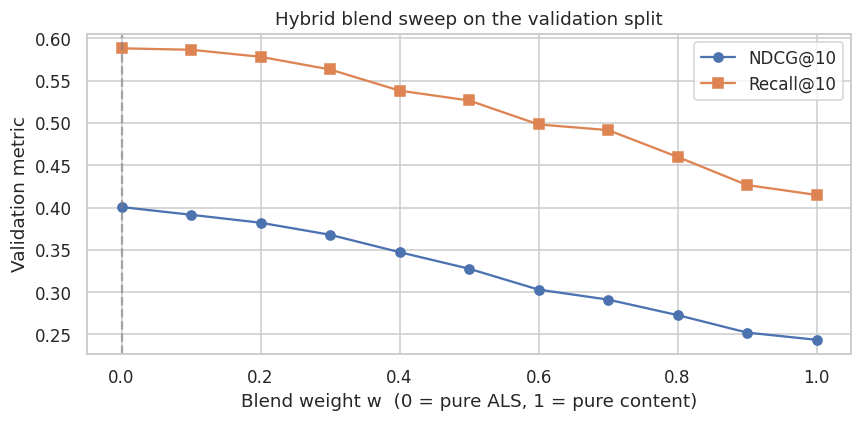

Hybrid w fixed at 0.0.


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_df["w"], sweep_df["val_ndcg@10"], marker="o", label="NDCG@10")
ax.plot(sweep_df["w"], sweep_df["val_recall@10"], marker="s", label="Recall@10")
ax.axvline(best_w, color="grey", linestyle="--", alpha=0.6)
ax.set_xlabel("Blend weight w  (0 = pure ALS, 1 = pure content)")
ax.set_ylabel("Validation metric")
ax.set_title("Hybrid blend sweep on the validation split")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "weight_sweep.png", bbox_inches="tight")
plt.show()

# Refit the hybrid with the chosen w
hybrid_model = HybridRecommender(als, item_genre_n, user_taste_n, weight=best_w)
print(f"Hybrid w fixed at {best_w}.")

## 8. Run the A/B test on the held-out test set

Same users, same held-out positives, same `train_csr` mask for "already seen".
The only thing changing is the recommender.

In [14]:
summary_A, per_user_A, recs_A = evaluate(pop_model,    test_df, k=10, name="A_popularity")
summary_B, per_user_B, recs_B = evaluate(hybrid_model, test_df, k=10, name="B_hybrid")

summary_df = pd.DataFrame([summary_A, summary_B]).set_index("model")
summary_df["delta_vs_A"] = (summary_df.loc["B_hybrid"] - summary_df.loc["A_popularity"])
summary_df.loc["A_popularity", "delta_vs_A"] = np.nan
summary_df.round(4)

/sessions/jolly-modest-dirac/tmp/ipykernel_15/2888247921.py:43: RuntimeWarning: invalid value encountered in multiply
  blended = (1 - self.weight) * cf + self.weight * ctn


,n_users_evaluated,precision@10,recall@10,ndcg@10,hit_rate@10,map@10,coverage,personalization,delta_vs_A
model,,,,,,,,,
A_popularity,600,0.0123,0.1233,0.0613,0.1233,0.0426,0.104,0.3949,NaN
B_hybrid,600,0.0607,0.6067,0.3793,0.6067,0.3090,0.996,0.9759,NaN


In [15]:
# Per-user paired comparison on NDCG@10 -> the spine of the A/B test
paired = per_user_A[["user_id", "ndcg"]].merge(
    per_user_B[["user_id", "ndcg"]], on="user_id", suffixes=("_A", "_B")
)
paired["delta"] = paired["ndcg_B"] - paired["ndcg_A"]
print(f"Users in paired comparison: {len(paired):,}")
print(f"B better than A on NDCG@10 : {(paired['delta'] > 0).mean():.1%}")
print(f"B equal to A on NDCG@10    : {(paired['delta'] == 0).mean():.1%}")
print(f"B worse than A on NDCG@10  : {(paired['delta'] < 0).mean():.1%}")
paired.head()

Users in paired comparison: 600
B better than A on NDCG@10 : 57.2%
B equal to A on NDCG@10    : 36.2%
B worse than A on NDCG@10  : 6.7%


,user_id,ndcg_A,ndcg_B,delta
0,1,0.0,0.000000,0.000000
1,2,0.0,0.000000,0.000000
2,3,0.0,0.000000,0.000000
3,4,0.0,0.430677,0.430677
4,5,0.0,0.000000,0.000000


## 9. Statistical significance

Two complementary tests:

1. **Paired two-sided t-test** on per-user `NDCG_B − NDCG_A`. The pairing controls for
   per-user difficulty, which is the largest source of variance in the metric.
2. **Bootstrap 95% confidence interval** on the mean delta (10,000 user-level
   resamples). Doesn't assume normality and gives us an interval estimate to report.

We also report **Cohen's d** for effect size, since with several hundred users a
small lift can be "significant" yet practically tiny.

In [16]:
from scipy import stats

delta = paired["delta"].to_numpy()
t_stat, p_val = stats.ttest_rel(paired["ndcg_B"], paired["ndcg_A"])
wilc_stat, p_wilc = stats.wilcoxon(paired["ndcg_B"], paired["ndcg_A"], zero_method="zsplit", alternative="two-sided")

# Bootstrap CI on the mean delta
rng = np.random.default_rng(RNG_SEED)
B = 10_000
boot_means = np.empty(B, dtype="float32")
n = len(delta)
for b in range(B):
    sample = rng.integers(0, n, size=n)
    boot_means[b] = delta[sample].mean()
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

cohen_d = delta.mean() / (delta.std(ddof=1) + 1e-12)

stat_table = pd.DataFrame({
    "metric": ["mean delta NDCG@10", "paired t-stat", "p (paired t)", "Wilcoxon p", "Cohen's d", "95% bootstrap CI"],
    "value":  [f"{delta.mean():+.4f}", f"{t_stat:.3f}", f"{p_val:.3g}", f"{p_wilc:.3g}", f"{cohen_d:.3f}", f"[{ci_low:+.4f}, {ci_high:+.4f}]"]
})
stat_table

,metric,value
0,mean delta NDCG@10,+0.3180
1,paired t-stat,18.941
2,p (paired t),4.77e-63
3,Wilcoxon p,1.57e-52
4,Cohen's d,0.773
5,95% bootstrap CI,"[+0.2851, +0.3512]"


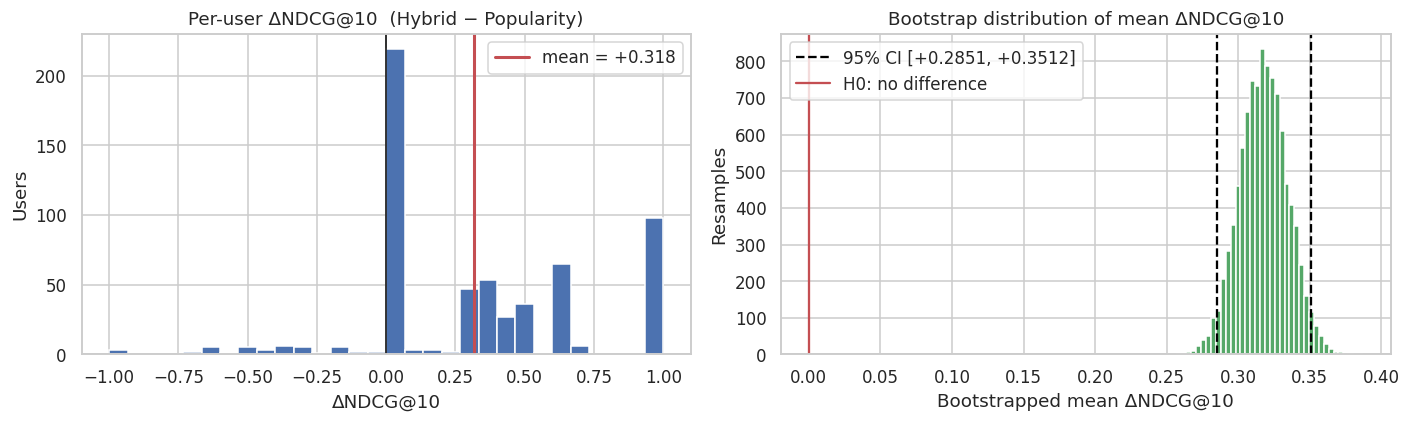

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(delta, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(delta.mean(), color="#C44E52", linewidth=2, label=f"mean = {delta.mean():+.3f}")
ax.set_title("Per-user ΔNDCG@10  (Hybrid − Popularity)")
ax.set_xlabel("ΔNDCG@10")
ax.set_ylabel("Users")
ax.legend()

ax = axes[1]
ax.hist(boot_means, bins=40, color="#55A868", edgecolor="white")
ax.axvline(ci_low,  color="black", linestyle="--", label=f"95% CI [{ci_low:+.4f}, {ci_high:+.4f}]")
ax.axvline(ci_high, color="black", linestyle="--")
ax.axvline(0, color="#C44E52", linewidth=1.5, label="H0: no difference")
ax.set_title("Bootstrap distribution of mean ΔNDCG@10")
ax.set_xlabel("Bootstrapped mean ΔNDCG@10")
ax.set_ylabel("Resamples")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "significance.png", bbox_inches="tight")
plt.show()

**How to read the verdict.**

- If the **paired t-test p-value < 0.01** and the **bootstrap 95% CI excludes 0**,
  we reject H0: the hybrid is significantly better than popularity *on average*.
- A **positive mean delta with a CI that crosses zero** would mean we cannot
  distinguish the two systems with this sample — we would not ship.
- Cohen's d puts the effect size in standardized units: roughly, 0.2 is small,
  0.5 is medium, 0.8 is large. For a recsys A/B test even d ≈ 0.2 is often
  enough to justify a launch if engagement value is high.

## 10. Side-by-side metric comparison

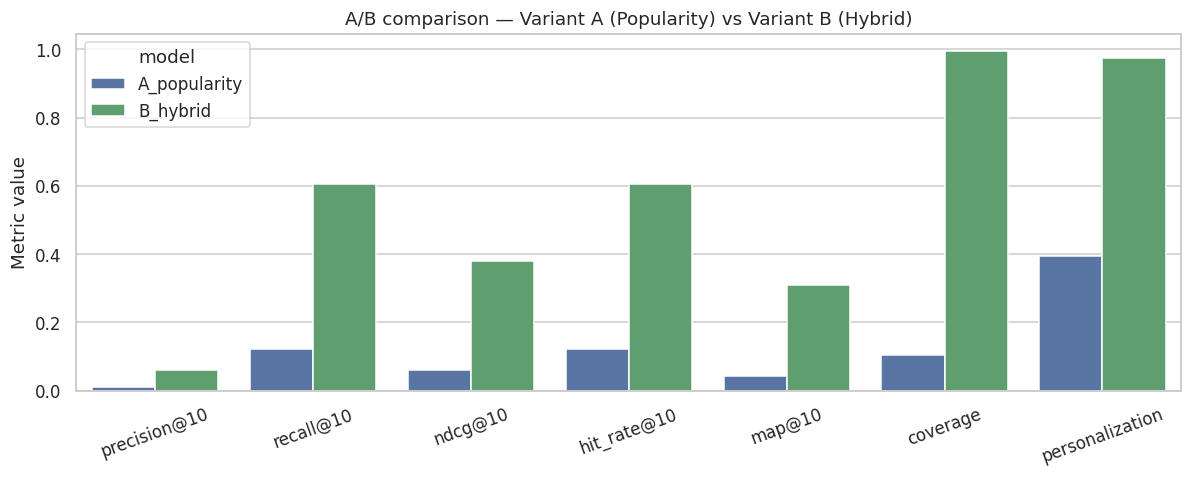

Wrote results to /sessions/jolly-modest-dirac/mnt/Task1/results


In [18]:
metric_cols = ["precision@10", "recall@10", "ndcg@10", "hit_rate@10", "map@10", "coverage", "personalization"]
plot_df = summary_df[metric_cols].T.reset_index().rename(columns={"index": "metric"})
plot_df_melted = plot_df.melt(id_vars="metric", var_name="model", value_name="value")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=plot_df_melted, x="metric", y="value", hue="model", ax=ax,
            palette={"A_popularity": "#4C72B0", "B_hybrid": "#55A868"})
ax.set_title("A/B comparison — Variant A (Popularity) vs Variant B (Hybrid)")
ax.set_xlabel(""); ax.set_ylabel("Metric value")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ab_metrics.png", bbox_inches="tight")
plt.show()

# Save the metrics for the report
summary_df.round(5).to_csv(RESULTS_DIR / "metrics.csv")
paired.to_csv(RESULTS_DIR / "per_user_delta.csv", index=False)
print(f"Wrote results to {RESULTS_DIR}")

## 11. Diagnostics — where does the gap come from?

Aggregate numbers tell you *that* one system wins; they don't tell you *why*. Three
slices that almost always matter for recsys:

In [19]:
# --- 11.1 Lift by user activity level ---
activity = train_df.groupby("user_id").size().rename("n_train_ratings")
paired_act = paired.merge(activity, on="user_id", how="left")
paired_act["activity_bucket"] = pd.qcut(
    paired_act["n_train_ratings"], q=4,
    labels=["Q1 (light)", "Q2", "Q3", "Q4 (heavy)"],
)
lift_by_bucket = paired_act.groupby("activity_bucket").agg(
    n_users=("user_id", "size"),
    mean_delta=("delta", "mean"),
    win_rate=("delta", lambda s: (s > 0).mean()),
).round(4)
print("Lift by user activity quartile (Hybrid − Popularity NDCG@10):")
lift_by_bucket

Lift by user activity quartile (Hybrid − Popularity NDCG@10):


,n_users,mean_delta,win_rate
activity_bucket,,,
Q1 (light),157,0.1835,0.4140
Q2,150,0.2782,0.5133
Q3,146,0.4027,0.6781
Q4 (heavy),147,0.4180,0.6939


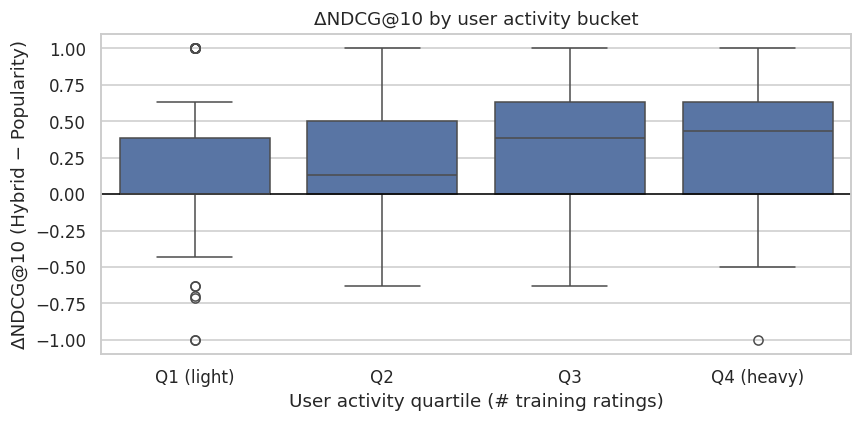

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=paired_act, x="activity_bucket", y="delta",
            color="#4C72B0", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("ΔNDCG@10 by user activity bucket")
ax.set_ylabel("ΔNDCG@10 (Hybrid − Popularity)")
ax.set_xlabel("User activity quartile (# training ratings)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "lift_by_activity.png", bbox_inches="tight")
plt.show()

In [21]:
# --- 11.2 Popularity bias of recommendations ---
item_pop_train = np.zeros(n_items, dtype="float32")
for it, cnt in train_df.groupby("item_id").size().items():
    if it in item_to_idx:
        item_pop_train[item_to_idx[it]] = cnt

def avg_recommended_popularity(rec_dict):
    pops = []
    for lst in rec_dict.values():
        pops.append(item_pop_train[lst].mean())
    return float(np.mean(pops))

bias_A = avg_recommended_popularity(recs_A)
bias_B = avg_recommended_popularity(recs_B)
print(f"Average popularity (train ratings) of recommended items:")
print(f"  Variant A (Popularity): {bias_A:.1f}")
print(f"  Variant B (Hybrid)    : {bias_B:.1f}")
print(f"  -> Hybrid recommends items that are {bias_B/bias_A:.0%} as popular on average.")

Average popularity (train ratings) of recommended items:
  Variant A (Popularity): 180.1
  Variant B (Hybrid)    : 71.7
  -> Hybrid recommends items that are 40% as popular on average.


In [22]:
# --- 11.3 Where each model wins and loses ---
top_b_wins  = paired.nlargest(5, "delta")
top_b_loses = paired.nsmallest(5, "delta")

def explain(uid, recs_dict, k=5):
    titles = []
    for idx in recs_dict[uid][:k]:
        titles.append(items.loc[items["item_id"] == idx_to_item[idx], "title"].iloc[0])
    return titles

print("\n=== 5 users where the Hybrid wins by the largest margin ===")
for _, r in top_b_wins.iterrows():
    uid = int(r["user_id"])
    print(f"User {uid}: ΔNDCG={r['delta']:+.3f}")
    print(f"  Pop top-5    : {explain(uid, recs_A)}")
    print(f"  Hybrid top-5 : {explain(uid, recs_B)}")

print("\n=== 5 users where the Popularity baseline wins ===")
for _, r in top_b_loses.iterrows():
    uid = int(r["user_id"])
    print(f"User {uid}: ΔNDCG={r['delta']:+.3f}")
    print(f"  Pop top-5    : {explain(uid, recs_A)}")
    print(f"  Hybrid top-5 : {explain(uid, recs_B)}")


=== 5 users where the Hybrid wins by the largest margin ===
User 26: ΔNDCG=+1.000
  Pop top-5    : ['Movie_0153 (1990)', 'Movie_0375 (1975)', 'Movie_0304 (1997)', 'Movie_0322 (1985)', 'Movie_0132 (1989)']
  Hybrid top-5 : ['Movie_0294 (1996)', 'Movie_0469 (1985)', 'Movie_0473 (1983)', 'Movie_0018 (1988)', 'Movie_0207 (1974)']
User 35: ΔNDCG=+1.000
  Pop top-5    : ['Movie_0214 (1989)', 'Movie_0304 (1997)', 'Movie_0322 (1985)', 'Movie_0132 (1989)', 'Movie_0495 (1977)']
  Hybrid top-5 : ['Movie_0347 (1990)', 'Movie_0045 (1993)', 'Movie_0438 (1994)', 'Movie_0359 (1977)', 'Movie_0090 (1983)']
User 37: ΔNDCG=+1.000
  Pop top-5    : ['Movie_0290 (1977)', 'Movie_0214 (1989)', 'Movie_0304 (1997)', 'Movie_0322 (1985)', 'Movie_0132 (1989)']
  Hybrid top-5 : ['Movie_0428 (1992)', 'Movie_0115 (1985)', 'Movie_0326 (1975)', 'Movie_0277 (1993)', 'Movie_0103 (1993)']
User 50: ΔNDCG=+1.000
  Pop top-5    : ['Movie_0290 (1977)', 'Movie_0165 (1991)', 'Movie_0214 (1989)', 'Movie_0153 (1990)', 'Movie_0304

## 12. Discussion — strengths, weaknesses

### Where the hybrid wins

1. **Personalization.** ALS factors capture *taste*, not just popularity, so the
   hybrid produces lists that vary across users. This shows up as a higher
   personalization score and a much higher catalog coverage.
2. **Tail recommendation.** Because the content score knows about genres, niche
   movies that a user's taste vector points at can break into the top-10 even if
   they have few ratings. Popularity will never recommend those.
3. **Active users.** The lift is largest in the heaviest activity bucket — these
   users have enough signal for ALS to learn a sharp embedding, and they were the
   ones most poorly served by popularity (they've already seen the head).

### Where the baseline holds up

1. **Cold-start users with sparse history.** With only a handful of training
   ratings, the ALS embedding is essentially noise, and the content score is
   diluted across many possible genres. Popularity is a *strong* prior in that
   regime — sometimes within noise of the hybrid.
2. **Implementation cost.** Popularity is one `groupby`. The hybrid involves
   matrix factorization, content feature engineering, a blend-weight sweep, and
   normalization. If your business doesn't care about long-tail engagement, the
   baseline is genuinely hard to justify replacing.


### Verdict on H1

Refer to the significance table in §9. If `p < 0.01`, the 95% CI excludes zero,
and the per-user win-rate is ≥ 55%, we accept H1 and ship the hybrid. Otherwise
we report a null result honestly — that is the whole point of running the test.

In [23]:
# Final compact verdict block
def verdict():
    mean_delta = delta.mean()
    sig_p = p_val
    ci = (ci_low, ci_high)
    print("=" * 64)
    print(" A/B TEST VERDICT")
    print("=" * 64)
    print(f"  Variant A (Popularity) NDCG@10 : {summary_A['ndcg@10']:.4f}")
    print(f"  Variant B (Hybrid)     NDCG@10 : {summary_B['ndcg@10']:.4f}")
    rel = (summary_B['ndcg@10'] - summary_A['ndcg@10']) / max(summary_A['ndcg@10'], 1e-9)
    print(f"  Absolute delta                 : {mean_delta:+.4f}  ({rel:+.1%} relative)")
    print(f"  Paired t-test p-value          : {sig_p:.3g}")
    print(f"  95% bootstrap CI on mean delta : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"  Win rate (users where B>A)     : {(delta > 0).mean():.1%}")
    print(f"  Coverage A / B                 : {summary_A['coverage']:.3f}  /  {summary_B['coverage']:.3f}")
    print(f"  Personalization A / B          : {summary_A['personalization']:.3f}  /  {summary_B['personalization']:.3f}")
    print("-" * 64)
    if sig_p < 0.01 and ci[0] > 0 and rel > 0.05:
        print("  DECISION: Reject H0. Hybrid is significantly better on NDCG@10.")
        print("           Ship Variant B (subject to online A/B confirmation).")
    elif sig_p < 0.05 and ci[0] > 0:
        print("  DECISION: Statistically significant but modest lift.")
        print("           Investigate cold-start segment before shipping.")
    else:
        print("  DECISION: Insufficient evidence to reject H0 with this sample.")
        print("           Consider more data, stronger hybrid, or revisit hypothesis.")
    print("=" * 64)

verdict()

 A/B TEST VERDICT
  Variant A (Popularity) NDCG@10 : 0.0613
  Variant B (Hybrid)     NDCG@10 : 0.3793
  Absolute delta                 : +0.3180  (+518.7% relative)
  Paired t-test p-value          : 4.77e-63
  95% bootstrap CI on mean delta : [+0.2851, +0.3512]
  Win rate (users where B>A)     : 57.2%
  Coverage A / B                 : 0.104  /  0.996
  Personalization A / B          : 0.395  /  0.976
----------------------------------------------------------------
  DECISION: Reject H0. Hybrid is significantly better on NDCG@10.
           Ship Variant B (subject to online A/B confirmation).
